# top

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%load_ext autoreload
%autoreload 2

['/mnt/ceph/users/blyo1/projects', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages']


# ddpm sos

In [26]:
from b_models.ddpm.ddpm_inference import DDPM_Inference
from b_models.ddpm.ddpm_lightning import DDPM_Lightning
from b_models.configs.sami_config import SelectConfig
from utils.model_init import init_ddpm_model
from utils.wandb_utils import get_artifact

project_name = "ddpm_sos"
model_num = 2
artifact_id = "v16"

# construct config from wandb run
model_path, artifact, config, run_config = get_artifact(model_num=model_num, project_name=project_name)
config = SelectConfig.from_dict(run_config)

ddpm = init_ddpm_model(config)
ddpm_lightning = DDPM_Lightning.load_from_checkpoint(model_path, config=config).model
ddpm_inference = DDPM_Inference(ddpm_lightning, config).to(device)

/mnt/home/blyo1/hdiva/c_training/lightning_checkpoints/ddpm_sos
wandb run name: plvq83ed


wandb:   1 of 1 files downloaded.  


In [27]:
from a_datasets.sos.data import load_sos_data

cpu_tensor, (square_targets, circle_targets) = load_sos_data(num_samples=1000, grid_size=config.image_dim)
print(cpu_tensor.shape)
print(cpu_tensor.min(), cpu_tensor.max())
print(square_targets.shape, circle_targets.shape)

# print(config.dataset_size)

torch.Size([1000, 1, 28, 28])
tensor(0.) tensor(0.9999)
(1000,) (1000,)


In [28]:
from torchvision import transforms

from a_datasets.custom_dataset_classes import CustomTensorDataset

transform = transforms.Compose(
    [
        transforms.Normalize((0.5,), (0.5,)),
    ]
)
train_dataset = CustomTensorDataset(cpu_tensor, transform)

input_img = train_dataset[31]
print(input_img.shape)
print(input_img.min())
print(input_img.max())


torch.Size([1, 28, 28])
tensor(-1.)
tensor(0.9896)


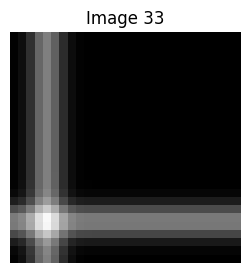

-1.0 0.9474117755889893
---
-1.0 0.9474118


In [29]:
from utils.base_utils import t2n, to_01

"""select an image from cis dataset"""
img_idx = 33
target_img = t2n(train_dataset[img_idx])
target_img = np.transpose(target_img, (1,2,0))

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(target_img, cmap='gray', vmin=-1, vmax=1)
ax.axis('off')
ax.set_title(f"Image {img_idx}")
plt.show()

print(train_dataset[img_idx].min().item(), train_dataset[img_idx].max().item())
print('---')
print(target_img.min(), target_img.max())

In [30]:
"""generate images from sami_inference"""
ddpm_inference.unconditional_sample(N=4)
gen_img = ddpm_inference.x_t
print(gen_img.shape)
print(gen_img.min(), gen_img.max())

torch.Size([4, 1, 28, 28])
tensor(-1.0372, device='cuda:0') tensor(0.9989, device='cuda:0')


(28, 28, 1)
(4, 28, 28, 1)
-0.018613875 0.9994419


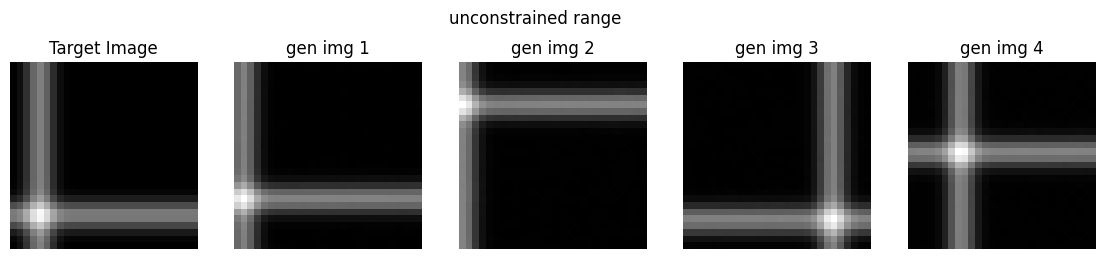

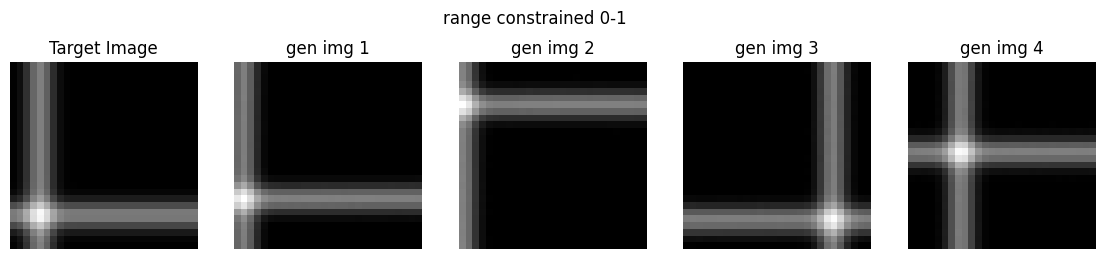

In [31]:
# figure
target_img = t2n(train_dataset[img_idx])
target_img = np.transpose(target_img, (1,2,0))
target_img = to_01(target_img)
print(target_img.shape)

gen_img_np = t2n(gen_img)
gen_img_np = np.transpose(gen_img_np, (0,2,3,1))
gen_img_np = to_01(gen_img_np)
print(gen_img_np.shape)
print(gen_img_np.min(), gen_img_np.max())


fig, ax = plt.subplots(1,5, figsize=(14,3))
ax[0].imshow(target_img, vmin=0, vmax=1, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Target Image')
for i in range(1,5):
    # ax[i].imshow(gen_img_np[i-1], vmin=0, vmax=1, cmap='gray')
    ax[i].imshow(gen_img_np[i-1], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'gen img {i}')
fig.suptitle('unconstrained range')
plt.show()

fig, ax = plt.subplots(1,5, figsize=(14,3))
ax[0].imshow(target_img, vmin=0, vmax=1, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Target Image')
for i in range(1,5):
    ax[i].imshow(gen_img_np[i-1], vmin=0, vmax=1, cmap='gray')
    # ax[i].imshow(gen_img_np[i-1], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'gen img {i}')
fig.suptitle('range constrained 0-1')
# fig.tight_layout()
plt.show()
# ax[1].axis('off')
# ax[1].set_title('Generated Image')

min tensor(-1., device='cuda:0') max tensor(0.9974, device='cuda:0')
shape torch.Size([1, 1, 28, 28])
device cuda:0
(28, 28)


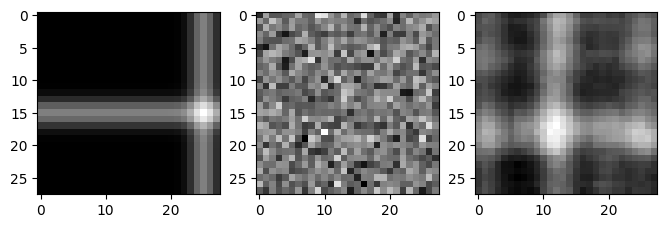

In [32]:
from utils.base_utils import check_input

img_idx = 59
input_image = train_dataset[img_idx].unsqueeze(0).to(device)
check_input(input_image)
t = 90
x0_hat, noisy_x = ddpm_inference.add_noise_and_denoise(input_image, t=t)
input_image = input_image.squeeze().cpu()
noisy_x = noisy_x.squeeze().detach().cpu().numpy()
x0_hat = x0_hat.squeeze().detach().cpu().numpy()
print(x0_hat.shape)

fig, ax = plt.subplots(1, 3, figsize=(8, 4))
ax[0].imshow(input_image, cmap="grey")
ax[1].imshow(noisy_x, cmap="grey")
ax[2].imshow(x0_hat, cmap="grey")

In [33]:
from tqdm import tqdm

# plot one shot denoising mse as a function of noise level
img_idxs = [1, 2, 3, 4, 5]
all_mses_ = np.empty((len(img_idxs), config.num_timesteps))
for j, img_idx in tqdm(enumerate(img_idxs)):
    input_image = train_dataset[img_idx].unsqueeze(0).to(device)
    for i in range(1, config.num_timesteps):
        x0_hat, _ = ddpm_inference.add_noise_and_denoise(input_image, t=i)
        input_image_cpu = input_image.squeeze().cpu()
        x0_hat_cpu = x0_hat.squeeze().detach().cpu()
        mse = F.mse_loss(x0_hat_cpu, input_image_cpu).item()
        all_mses_[j, i] = mse

5it [00:00,  6.02it/s]


torch.Size([1, 1, 28, 28])
tensor(-1., device='cuda:0')
[10 20 30 40 50 60 70 80 90 99]
torch.Size([1, 1, 28, 28])
tensor(-0.8793, device='cuda:0', grad_fn=<MinBackward1>) tensor(-0.6574, device='cuda:0', grad_fn=<MaxBackward1>)


[Text(0, 0.5, 'Denoised')]

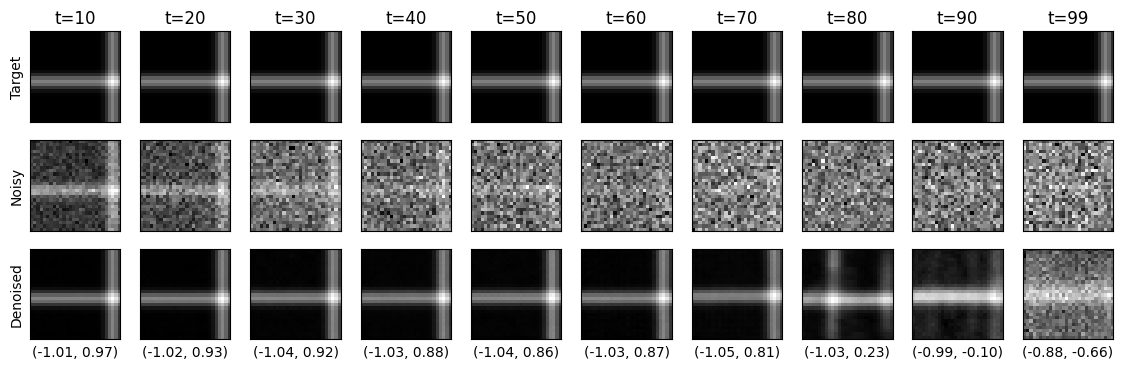

In [34]:
"""generate images from ddpm_inference"""
img_idx = 59
target_img = train_dataset[img_idx].unsqueeze(0).to(device)
print(target_img.shape)
print(target_img.min())

t_vals = np.linspace(10, config.num_timesteps, config.num_timesteps//10)
t_vals[-1] = config.num_timesteps-1
t_vals = t_vals.astype(int)
print(t_vals)

one_shot_denoising_estimates = torch.empty(len(t_vals), *target_img.shape)
noisy_xs = torch.empty(len(t_vals), *target_img.shape)

for i, t in enumerate(t_vals):
    x0_hat, noisy_x = ddpm_inference.add_noise_and_denoise(target_img, t=t)
    noisy_xs[i] = noisy_x.cpu().squeeze()
    one_shot_denoising_estimates[i] = x0_hat.cpu().squeeze()
    

print(x0_hat.shape)
print(x0_hat.min(), x0_hat.max())

fig, ax = plt.subplots(3, len(t_vals), figsize=(14, 4))
for i in range(len(t_vals)):
    ax[0, i].imshow(target_img.cpu().squeeze(), cmap="grey")
    ax[0,i].set(title=f"t={t_vals[i]}")
    noisy_x = noisy_xs[i].cpu().squeeze()
    ax[1,i].imshow(noisy_x, cmap="grey")
    x0_hat = one_shot_denoising_estimates[i].squeeze().detach().cpu()
    ax[2,i].imshow(x0_hat, cmap="grey")
    ax[2,i].set(xlabel=f"({x0_hat.min():.2f}, {x0_hat.max():.2f})")

for i in range(len(t_vals)):
    ax[0,i].set(xticks=[], yticks=[])
    ax[1,i].set(xticks=[], yticks=[])
    ax[2,i].set(xticks=[], yticks=[])

ax[0,0].set(ylabel="Target")
ax[1,0].set(ylabel="Noisy")
ax[2,0].set(ylabel="Denoised")

# mse = F.mse_loss(target_img, x0_hat)
# print(mse)

# print(x0_hat.min(), x0_hat.max())

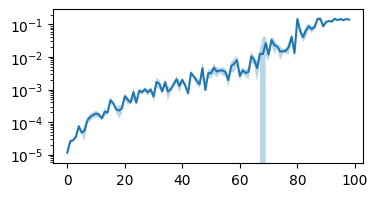

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(4, 2))

all_mses = all_mses_[:, 1:]
mean = all_mses[1:].mean(axis=0)
sem = all_mses.std(axis=0) / np.sqrt(all_mses.shape[0])
x = np.arange(len(mean))

ax.plot(x, mean)
ax.fill_between(x, mean-sem, mean+sem, alpha=.3)
ax.set_yscale('log')

# sami sos

In [128]:
from b_models.sami.sami_inference import SAMI_Inference
from b_models.sami.sami_lightning import SAMI_Lightning
from b_models.configs.sami_config import SAMI_SOS_Training_Config, SelectConfig
from utils.model_init import init_sami_model
from utils.wandb_utils import get_artifact

project_name = "sami_sos"
# model_num = 21
# artifact_id = "v16" 
model_num = 34
artifact_id = "latest"

# construct config from wandb run
model_path, artifact, config, run_config = get_artifact(model_num=model_num, project_name=project_name)
config = SAMI_SOS_Training_Config.from_dict(run_config)

# config.noise_schedule = "reverse_linear_in_alpha_bar"
sami = init_sami_model(config)
sami_lightning = SAMI_Lightning.load_from_checkpoint(model_path, config=config).model
sami_inference = SAMI_Inference(sami_lightning, config).to(device)

/mnt/home/blyo1/hdiva/c_training/lightning_checkpoints/sami_sos
wandb run name: 49d7grxy


wandb:   1 of 1 files downloaded.  


In [129]:
from a_datasets.sos.data import load_sos_data

cpu_tensor, (square_targets, circle_targets) = load_sos_data(num_samples=1000, grid_size=config.image_dim, sigma_x=config.sigma_x, sigma_y=config.sigma_y)
print(cpu_tensor.shape)
print(cpu_tensor.min(), cpu_tensor.max())
print(square_targets.shape, circle_targets.shape)

# print(config.dataset_size)

torch.Size([1000, 1, 28, 28])
tensor(7.7349e-39) tensor(0.9999)
(1000,) (1000,)


In [130]:
from torchvision import transforms

from a_datasets.custom_dataset_classes import CustomTensorDataset

transform = transforms.Compose(
    [
        transforms.Normalize((0.5,), (0.5,)),
    ]
)
train_dataset = CustomTensorDataset(cpu_tensor, transform)

input_img = train_dataset[31]
print(input_img.shape)
print(input_img.min())
print(input_img.max())


torch.Size([1, 28, 28])
tensor(-1.)
tensor(0.9838)


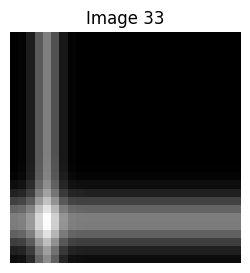

-1.0 0.9754680395126343
---
-1.0 0.97546804


In [131]:
from utils.base_utils import t2n, to_01

"""select an image from cis dataset"""
img_idx = 33
target_img = t2n(train_dataset[img_idx])
target_img = np.transpose(target_img, (1,2,0))

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(target_img, cmap='gray', vmin=-1, vmax=1)
ax.axis('off')
ax.set_title(f"Image {img_idx}")
plt.show()

print(train_dataset[img_idx].min().item(), train_dataset[img_idx].max().item())
print('---')
print(target_img.min(), target_img.max())

In [132]:
"""generate images from sami_inference"""
target_img = train_dataset[img_idx].unsqueeze(0).to(device)
print(target_img.shape)
sami_inference.conditional_sample(N=4, target_image_input=target_img)
gen_img = sami_inference.x_t
print(gen_img.shape)
print(gen_img.min(), gen_img.max())

torch.Size([1, 1, 28, 28])
torch.Size([4, 1, 28, 28])
tensor(-1.0117, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.9927, device='cuda:0', grad_fn=<MaxBackward1>)


(28, 28, 1)
(4, 28, 28, 1)
-0.005861461 0.9963258


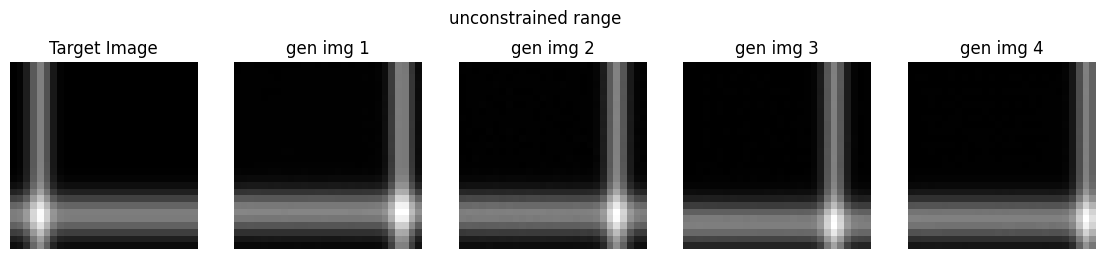

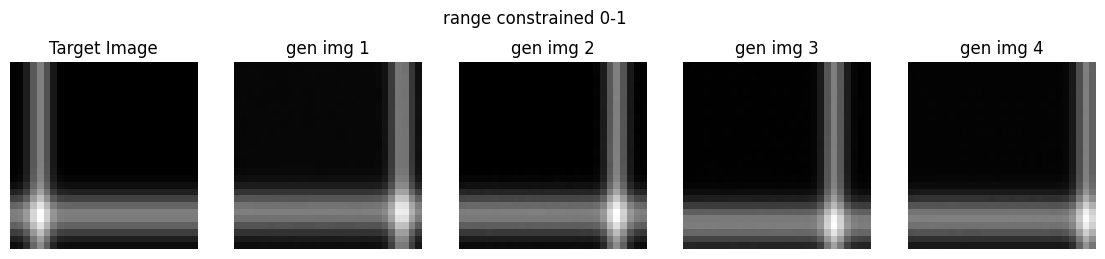

In [133]:
# figure
target_img = t2n(train_dataset[img_idx])
target_img = np.transpose(target_img, (1,2,0))
target_img = to_01(target_img)
print(target_img.shape)

gen_img_np = t2n(gen_img)
gen_img_np = np.transpose(gen_img_np, (0,2,3,1))
gen_img_np = to_01(gen_img_np)
print(gen_img_np.shape)
print(gen_img_np.min(), gen_img_np.max())


fig, ax = plt.subplots(1,5, figsize=(14,3))
ax[0].imshow(target_img, vmin=0, vmax=1, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Target Image')
for i in range(1,5):
    # ax[i].imshow(gen_img_np[i-1], vmin=0, vmax=1, cmap='gray')
    ax[i].imshow(gen_img_np[i-1], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'gen img {i}')
fig.suptitle('unconstrained range')
plt.show()

fig, ax = plt.subplots(1,5, figsize=(14,3))
ax[0].imshow(target_img, vmin=0, vmax=1, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Target Image')
for i in range(1,5):
    ax[i].imshow(gen_img_np[i-1], vmin=0, vmax=1, cmap='gray')
    # ax[i].imshow(gen_img_np[i-1], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'gen img {i}')
fig.suptitle('range constrained 0-1')
# fig.tight_layout()
plt.show()
# ax[1].axis('off')
# ax[1].set_title('Generated Image')

[ 0 10 20 30 40 50 60 70 80 90 99]


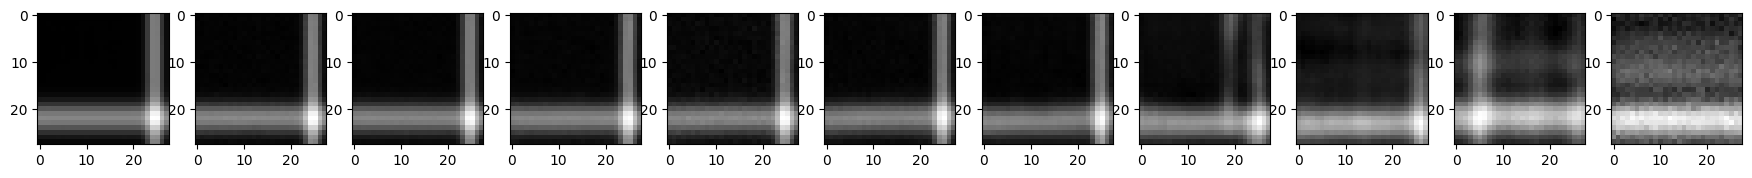

In [134]:
x0_estimates = sami_inference.x0_estimates
t_vals = np.linspace(0, config.num_timesteps, 11)
t_vals[-1] = config.num_timesteps-1
t_vals = t_vals.astype(int)
print(t_vals)

fig, ax = plt.subplots(1,11, figsize=(22,2))
for i, t in enumerate(t_vals):
    ax[i].imshow(x0_estimates[t, 0, 0].cpu().numpy(), cmap='gray')


In [135]:
for i, t in enumerate(t_vals):
    print(x0_estimates[t].min(), x0_estimates.max())

tensor(-1.0063) tensor(1.0082)
tensor(-1.0114) tensor(1.0082)
tensor(-1.0275) tensor(1.0082)
tensor(-1.0709) tensor(1.0082)
tensor(-1.0425) tensor(1.0082)
tensor(-1.0589) tensor(1.0082)
tensor(-1.0660) tensor(1.0082)
tensor(-1.1637) tensor(1.0082)
tensor(-1.1015) tensor(1.0082)
tensor(-1.0824) tensor(1.0082)
tensor(-1.2791) tensor(1.0082)


## add noise and denoise

torch.Size([1, 1, 28, 28])
torch.Size([1, 1, 28, 28])
tensor(-1.0046, device='cuda:0') tensor(0.9669, device='cuda:0')
tensor(4.9372e-05, device='cuda:0')
tensor(-1.0046, device='cuda:0') tensor(0.9669, device='cuda:0')


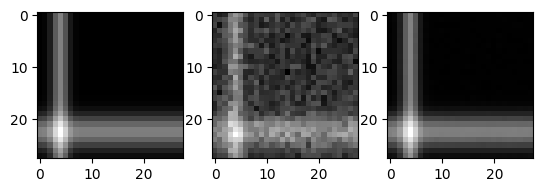

In [136]:
"""generate images from diva_inference"""
target_img = train_dataset[img_idx].unsqueeze(0).to(device)
print(target_img.shape)

x0_hat, noisy_x, pred_epsilon_guided = sami_inference.add_noise_and_denoise(
    target_image_input=target_img, t=10, x_t=None)

print(x0_hat.shape)
print(x0_hat.min(), x0_hat.max())

fig, ax = plt.subplots(1, 3)
ax[0].imshow(target_img.cpu().squeeze(), cmap="grey")
ax[1].imshow(noisy_x.cpu().squeeze(), cmap="grey")
ax[2].imshow(x0_hat.cpu().squeeze(), cmap="grey")

mse = F.mse_loss(target_img, x0_hat)
print(mse)

print(x0_hat.min(), x0_hat.max())

torch.Size([1, 1, 28, 28])
tensor(-1., device='cuda:0')
[10 20 30 40 50 60 70 80 90 99]
torch.Size([1, 1, 28, 28])
tensor(-1.4890, device='cuda:0') tensor(0.4126, device='cuda:0')


[Text(0, 0.5, 'Denoised')]

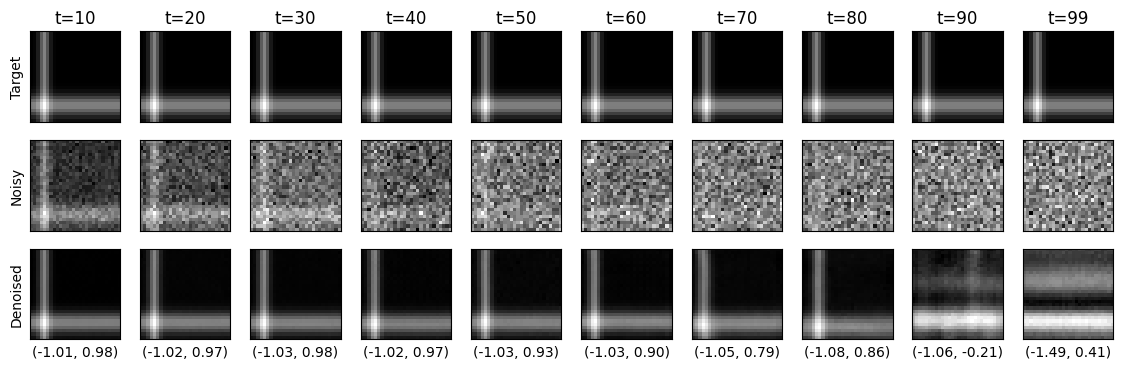

In [137]:
"""generate images from diva_inference"""
target_img = train_dataset[img_idx].unsqueeze(0).to(device)
print(target_img.shape)
print(target_img.min())

t_vals = np.linspace(10, config.num_timesteps, config.num_timesteps//10)
t_vals[-1] = config.num_timesteps-1
t_vals = t_vals.astype(int)
print(t_vals)

one_shot_denoising_estimates = torch.empty(len(t_vals), *target_img.shape)
noisy_xs = torch.empty(len(t_vals), *target_img.shape)

for i, t in enumerate(t_vals):
    x0_hat, noisy_x, pred_epsilon_guided = sami_inference.add_noise_and_denoise(
        target_image_input=target_img, t=t, x_t=None)
    noisy_xs[i] = noisy_x.cpu().squeeze()
    one_shot_denoising_estimates[i] = x0_hat.cpu().squeeze()
    

print(x0_hat.shape)
print(x0_hat.min(), x0_hat.max())

fig, ax = plt.subplots(3, len(t_vals), figsize=(14, 4))
for i in range(len(t_vals)):
    ax[0, i].imshow(target_img.cpu().squeeze(), cmap="grey")
    ax[0,i].set(title=f"t={t_vals[i]}")
    noisy_x = noisy_xs[i].cpu().squeeze()
    ax[1,i].imshow(noisy_x, cmap="grey")
    x0_hat = one_shot_denoising_estimates[i].squeeze()
    ax[2,i].imshow(x0_hat, cmap="grey")
    ax[2,i].set(xlabel=f"({x0_hat.min():.2f}, {x0_hat.max():.2f})")

for i in range(len(t_vals)):
    ax[0,i].set(xticks=[], yticks=[])
    ax[1,i].set(xticks=[], yticks=[])
    ax[2,i].set(xticks=[], yticks=[])

ax[0,0].set(ylabel="Target")
ax[1,0].set(ylabel="Noisy")
ax[2,0].set(ylabel="Denoised")

# mse = F.mse_loss(target_img, x0_hat)
# print(mse)

# print(x0_hat.min(), x0_hat.max())

/tmp/ipykernel_466151/562467733.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mse = F.mse_loss(one_shot_denoising_estimates[i].squeeze().cpu(), torch.tensor(target_img.squeeze()).cpu())


Text(0.5, 0, 't')

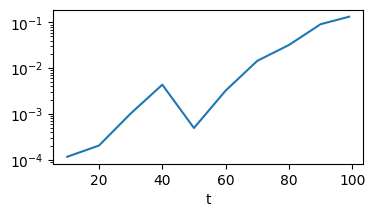

In [138]:
# plot the mse of the one shot denoising as a function of t
mse_values = []
for i, t in enumerate(t_vals):
    mse = F.mse_loss(one_shot_denoising_estimates[i].squeeze().cpu(), torch.tensor(target_img.squeeze()).cpu())
    mse_values.append(mse)

fig, ax = plt.subplots(1, 1, figsize=(4, 2))
ax.plot(t_vals, mse_values)
ax.set_yscale('log')
ax.set_xlabel('t')

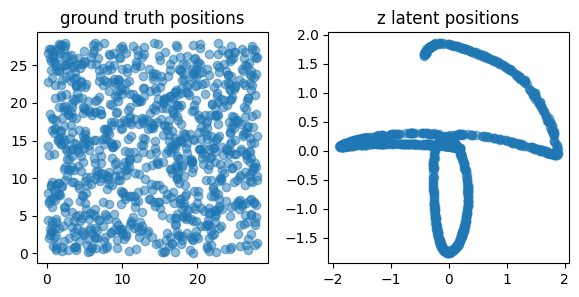

In [139]:
# encoder values
num_samples = 1000
cpu_tensor, targets = load_sos_data(num_samples=1000, grid_size=config.image_dim, sigma_x=config.sigma_x, sigma_y=config.sigma_y)
latents = np.empty((num_samples, config.latent_dim))
gt_sos_positions = np.empty((num_samples, 2))
targets = np.array(targets).T

for i in range(num_samples):
    target_img = train_dataset[i].unsqueeze(0).to(device)
    # print(target_img.shape)
    mu, _ = sami_inference.infnet(target_img)
    mu = mu.squeeze().detach().cpu().numpy()
    # print(z.shape)
    gt_sos_positions[i] = targets[i]
    latents[i] = mu

fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].scatter(*gt_sos_positions.T, alpha=0.5)
ax[0].set_aspect('equal')
ax[0].set(title="ground truth positions")
ax[1].scatter(*latents[:, 1:3].T, alpha=0.5)
ax[1].set_aspect('equal')
ax[1].set(title="z latent positions")

plt.show()

## get images that correspond to a specific value of x

torch.Size([28, 1, 28, 28])
(28, 4)


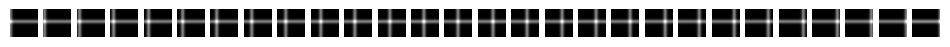

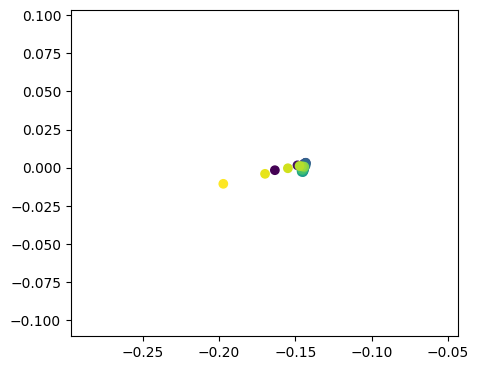

In [146]:
def generate_image(x, y, sigma=1., grid_size=28):
    xv, yv = np.meshgrid(np.arange(grid_size), np.arange(grid_size))
    sos_image = 0.5 * np.exp(-((xv - x) ** 2) / (4 * sigma**2)) + 0.5 * np.exp(
        -((yv - y) ** 2) / (4 * sigma**2)
    )
    return sos_image

x_vals = np.linspace(0, 28, 28)
y_val = 12
images = np.empty((len(x_vals), 28, 28))
fig, ax = plt.subplots(1, len(x_vals), figsize=(12, 4))
for i, x_val in enumerate(x_vals):
    images[i] = generate_image(x_val, y_val)
    ax[i].imshow(images[i], cmap='gray')
    ax[i].axis('off')


# plot the z latents
zaxis0 = 0
zaxis1 = 1
image_tensor = torch.tensor(images).unsqueeze(1).float().to(device)
print(image_tensor.shape)
z = sami_inference.infnet(image_tensor)[0].squeeze().detach().cpu().numpy()
print(z.shape)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(z[:, zaxis0], z[:, zaxis1], c=np.arange(len(z)), cmap='viridis')
zaxis_min = z[:, zaxis0].min(), z[:, zaxis1].min()
zaxis_max = z[:, zaxis0].max(), z[:, zaxis1].max()
ax.set(xlim=(zaxis_min[0]-.1, zaxis_max[0]+.1), ylim=(zaxis_min[1]-.1, zaxis_max[1]+.1))
ax.set_aspect('equal')

torch.Size([28, 1, 28, 28])
(28, 4)


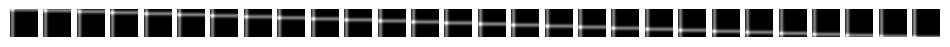

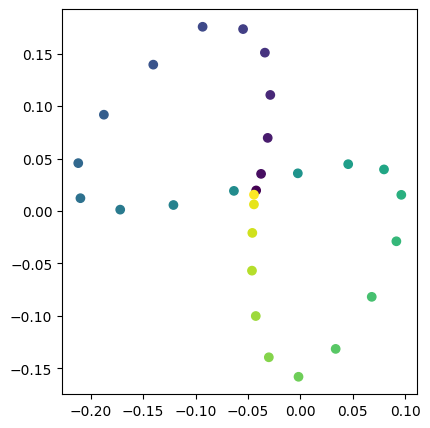

In [141]:
def generate_image(x, y, sigma=1., grid_size=28):
    xv, yv = np.meshgrid(np.arange(grid_size), np.arange(grid_size))
    sos_image = 0.5 * np.exp(-((xv - x) ** 2) / (4 * sigma**2)) + 0.5 * np.exp(
        -((yv - y) ** 2) / (4 * sigma**2)
    )
    return sos_image

x_val = 2
y_vals = np.linspace(0, 28, 28)
images = np.empty((len(y_vals), 28, 28))
fig, ax = plt.subplots(1, len(y_vals), figsize=(12, 4))
for i, y_val in enumerate(y_vals):
    images[i] = generate_image(x_val, y_val)
    ax[i].imshow(images[i], cmap='gray')
    ax[i].axis('off')


# plot the z latents
zaxis0 = 0
zaxis1 = 1
image_tensor = torch.tensor(images).unsqueeze(1).float().to(device)
print(image_tensor.shape)
z = sami_inference.infnet(image_tensor)[0].squeeze().detach().cpu().numpy()
print(z.shape)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(z[:, zaxis0], z[:, zaxis1], c=np.arange(len(z)), cmap='viridis')
zaxis_min = z[:, zaxis0].min(), z[:, zaxis1].min()
zaxis_max = z[:, zaxis0].max(), z[:, zaxis1].max()
# ax.set(xlim=(zaxis_min[0]-.1, zaxis_max[0]+.1), ylim=(zaxis_min[1]-.1, zaxis_max[1]+.1))
ax.set_aspect('equal')

# load model + data

In [ ]:
from b_models.sami.sami_inference import SAMI_Inference
from b_models.sami.sami_lightning import SAMI_Lightning
from b_models.configs.sami_config import SelectConfig
from utils.model_init import init_sami_model
from utils.wandb_utils import get_artifact

project_name = "sami_sos"
# project_name = "sami_bump"
model_num = 29
artifact_id = "799" 
# artifact_id = "575" 

# construct config from wandb run
model_path, artifact, config, run_config = get_artifact(model_num=model_num, project_name=project_name)
config = SelectConfig.from_dict(run_config)

# do conditional generation as a sanity check that the model has learned a good representation

sami = init_sami_model(config)
sami_lightning = SAMI_Lightning.load_from_checkpoint(model_path, config=config).model
sami_inference = SAMI_Inference(sami_lightning, config).to(device)
sami_inference.load_state_dict(sami_lightning.state_dict()) 

/mnt/home/blyo1/hdiva/c_training/lightning_checkpoints/sami_sos
wandb run name: zq2ci8aq


wandb:   1 of 1 files downloaded.  


<All keys matched successfully>

In [15]:
print(config.dataset_size)

100000


In [3]:
from a_datasets.bump.data import load_bump_data
from a_datasets.sos.data import load_sos_data

cpu_tensor, (x, y) = load_sos_data(holdout_center=False, num_samples=1000)
# cpu_tensor, (x, y) = load_bump_data(holdout_center=True, num_samples=config.dataset_size)
print(cpu_tensor.shape)
print(cpu_tensor.min(), cpu_tensor.max())
print(x, y)

torch.Size([1000, 1, 28, 28])
tensor(0.) tensor(0.9999)
[10.48712333 20.49583037  4.36852193  1.62634114 16.83122033  0.57636584
 23.30839394  5.09109908  8.5187828  12.09446052 17.13188105  8.18005016
 12.76995956  5.5908659  16.58760793 17.01125585  1.8214446  27.03769693
  8.52918554 19.15852474  3.41707058  0.96287859  7.24583948  8.72791013
 15.30788782 27.14836958 26.30597036 16.74119941  2.47779006  1.26636409
 10.88296411 23.20465026  7.86616627  3.9458783   2.08741802 21.62285354
  0.15461928 19.79200563 21.59556971 10.0370404  24.16689592  9.2651447
  8.70750501 20.42897299 24.84195679  3.34863889 21.30198136 21.58708104
 14.63651922  0.71173555  0.8800172   8.80196747 25.41186127 11.49072184
  6.40634863  8.11304068 26.03153427 17.73530518 22.50281815 24.99165196
 22.60832434  8.9040973   6.38218455 22.90441345  0.19465965 11.68750809
  3.35623029 26.40147171 14.52613741 10.18162887 26.94852426 13.92295816
  7.97553384 17.06780135  1.44140503 25.43144481  4.05705642 27.59821

In [4]:
from torchvision import transforms

from a_datasets.custom_dataset_classes import CustomTensorDataset

transform = transforms.Compose(
    [
        transforms.Normalize((0.5,), (0.5,)),
    ]
)
train_dataset = CustomTensorDataset(cpu_tensor, transform)

In [5]:
input_img = train_dataset[31]
print(input_img.shape)
print(input_img.min())
print(input_img.max())


torch.Size([1, 28, 28])
tensor(-1.)
tensor(0.9896)


(28, 28, 1)


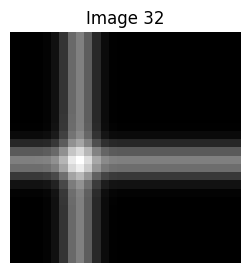

-1.0 0.9860235452651978
0.0 0.9930118


In [6]:
from utils.base_utils import t2n, to_01

"""select an image from bump dataset"""
img_idx = 32
target_img = t2n(train_dataset[img_idx])
target_img = np.transpose(target_img, (1,2,0))
target_img = to_01(target_img)
print(target_img.shape)
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(target_img, cmap='gray')
ax.axis('off')
ax.set_title(f"Image {img_idx}")
plt.show()

print(train_dataset[img_idx].min().item(), train_dataset[img_idx].max().item())
print(target_img.min(), target_img.max())

In [24]:
"""generate images from diva_inference"""
target_img = train_dataset[img_idx].unsqueeze(0).to(device)
print(target_img.shape)
sami_inference.conditional_sample(N=4, target_image_input=target_img)
gen_img = sami_inference.x_t
print(gen_img.shape)
print(gen_img.min(), gen_img.max())

torch.Size([1, 1, 28, 28])
torch.Size([4, 1, 28, 28])
tensor(nan, device='cuda:0', grad_fn=<MinBackward1>) tensor(nan, device='cuda:0', grad_fn=<MaxBackward1>)


(28, 28, 1)
(4, 28, 28, 1)
nan nan


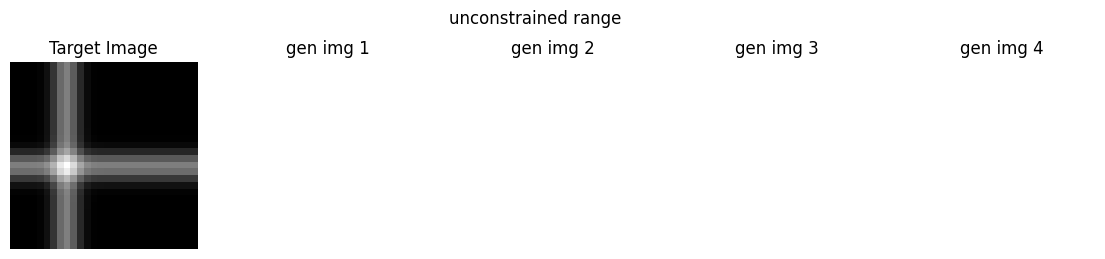

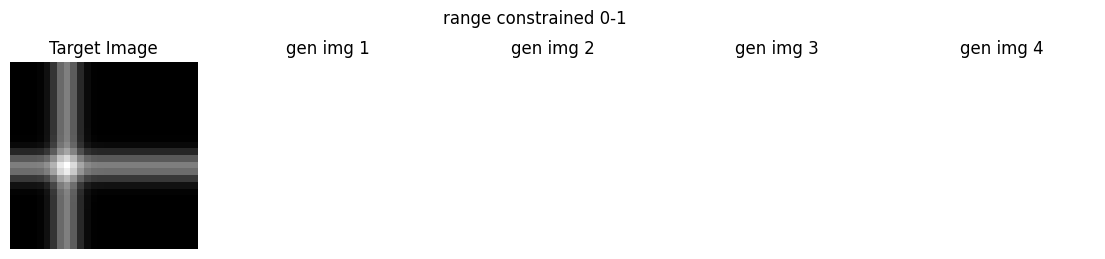

In [25]:
# figure
target_img = t2n(train_dataset[img_idx])
target_img = np.transpose(target_img, (1,2,0))
target_img = to_01(target_img)
print(target_img.shape)

gen_img_np = t2n(gen_img)
gen_img_np = np.transpose(gen_img_np, (0,2,3,1))
gen_img_np = to_01(gen_img_np)
print(gen_img_np.shape)
print(gen_img_np.min(), gen_img_np.max())


fig, ax = plt.subplots(1,5, figsize=(14,3))
ax[0].imshow(target_img, vmin=0, vmax=1, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Target Image')
for i in range(1,5):
    # ax[i].imshow(gen_img_np[i-1], vmin=0, vmax=1, cmap='gray')
    ax[i].imshow(gen_img_np[i-1], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'gen img {i}')
fig.suptitle('unconstrained range')
plt.show()

fig, ax = plt.subplots(1,5, figsize=(14,3))
ax[0].imshow(target_img, vmin=0, vmax=1, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Target Image')
for i in range(1,5):
    ax[i].imshow(gen_img_np[i-1], vmin=0, vmax=1, cmap='gray')
    # ax[i].imshow(gen_img_np[i-1], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'gen img {i}')
fig.suptitle('range constrained 0-1')
# fig.tight_layout()
plt.show()
# ax[1].axis('off')
# ax[1].set_title('Generated Image')

# add noise and denoise

In [11]:
"""generate images from diva_inference"""
target_img = train_dataset[img_idx].unsqueeze(0).to(device)
print(target_img.shape)

x0_hat, noisy_x, pred_epsilon_guided = sami_inference.add_noise_and_denoise(target_image_input=target_img, t=700, x_t=None)

print(x0_hat.shape)
print(x0_hat.min(), x0_hat.max())

torch.Size([1, 1, 28, 28])
torch.Size([1, 1, 28, 28])
tensor(-5.8065, device='cuda:0') tensor(2.5410, device='cuda:0')


tensor(6.6604, device='cuda:0')


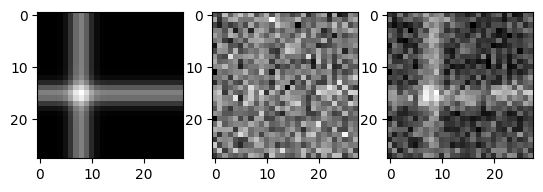

In [12]:
fig, ax = plt.subplots(1, 3)
ax[0].imshow(target_img.cpu().squeeze(), cmap="grey")
ax[1].imshow(noisy_x.cpu().squeeze(), cmap="grey")
ax[2].imshow(x0_hat.cpu().squeeze(), cmap="grey")

mse = F.mse_loss(target_img, x0_hat)
print(mse)

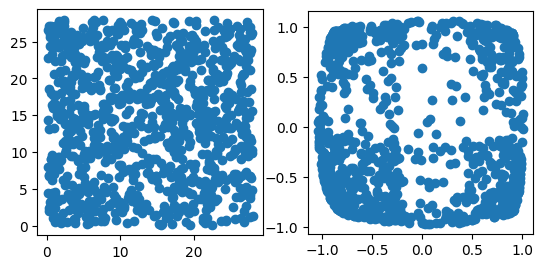

In [13]:
# encoder values
num_samples = 1000
latents = np.empty((num_samples, 2))
gt_positions = np.empty((num_samples, 2))

for i in range(num_samples):
    target_img = train_dataset[i]
    z = sami_inference.infnet(target_img.to(device))[0].detach().cpu().numpy()
    gt_positions[i] = (x[i], y[i])
    latents[i] = z

fig, ax = plt.subplots(1, 2)
ax[0].scatter(*gt_positions.T)
ax[0].set_aspect('equal')
ax[1].scatter(*latents.T)
ax[1].set_aspect('equal')

plt.show()